# NBA Draft Combine to NBA RAPM success
Calculate RAPM, run Ridge, Random Forest and Gradient Boosting (XGBoost) models to determine correlation between positional combine measurements and NBA success determined through RAPM

In [44]:
# ============================================================
# Load all sources
# ============================================================

import kagglehub
import pandas as pd

combine_data_path = kagglehub.dataset_download("marcusfern/nba-draft-combine")
nba_data_path     = kagglehub.dataset_download("eoinamoore/historical-nba-data-and-player-box-scores")

nba_draft_combine = pd.read_csv(f"{combine_data_path}/Draft Combine - Kaggle.csv")
player_stats      = pd.read_csv(f"{nba_data_path}/PlayerStatistics.csv", low_memory=False)
players_info      = pd.read_csv(f"{nba_data_path}/Players.csv")

# PLAYER column is "LastName, FirstName" — str[0] is last, str[1] is first
nba_draft_combine["lastName"]  = nba_draft_combine["PLAYER"].str.split(", ").str[0]
nba_draft_combine["firstName"] = nba_draft_combine["PLAYER"].str.split(", ").str[1]

# Normalise personId dtype across all three tables
for df in [players_info, player_stats]:
    df["personId"] = df["personId"].astype(str)

# ── Quick merge diagnostic ────────────────────────────────────────
test_merge = pd.merge(
    nba_draft_combine,
    players_info[["personId", "firstName", "lastName"]],
    on=["firstName", "lastName"],
    how="inner"
)
print(f"✅  Data loaded")
print(f"   combine rows       : {len(nba_draft_combine):,}")
print(f"   player_stats rows  : {len(player_stats):,}")
print(f"   players_info rows  : {len(players_info):,}")
print(f"\n   Name-match check   : {len(test_merge):,} combine players found in players_info")
if len(test_merge) == 0:
    print("\n   ⚠️  Still 0 matches — printing sample names from each side for inspection:")
    print("\n   Combine (firstName / lastName):")
    print(nba_draft_combine[["firstName","lastName"]].head(10).to_string(index=False))
    print("\n   players_info (firstName / lastName):")
    print(players_info[["firstName","lastName"]].head(10).to_string(index=False))
else:
    print(f"   Sample matched players:")
    print(test_merge[["PLAYER","firstName","lastName","personId"]].head(8).to_string(index=False))

✅  Data loaded
   combine rows       : 1,678
   player_stats rows  : 1,669,431
   players_info rows  : 6,692

   Name-match check   : 1,381 combine players found in players_info
   Sample matched players:
             PLAYER firstName    lastName personId
        Bailey, Ace       Ace      Bailey  1642846
       Bates, Tamar     Tamar       Bates  1642926
         Brea, Koby      Koby        Brea  1642886
      Broome, Johni     Johni      Broome  1641780
     Bryant, Carter    Carter      Bryant  1642868
Clayton Jr., Walter    Walter Clayton Jr.  1642383
    Clifford, Nique     Nique    Clifford  1642363
     Coward, Cedric    Cedric      Coward  1642907


## Build career RAPM metric for eligible players

In [52]:
# ============================================================
# Build career value metric from PlayerStatistics.csv
# ============================================================
#
# Target variable: career_avg_total_rapm
#   = mean +/− per 36 minutes, mean-centred so average NBA
#     player ≈ 0.  
#     * Not a true RAPM estimate (would require on/off + lineup data), but a solid proxy for overall impact.
#
# Also calculated:
#   career_avg_off_rapm  — Box Score Value per 36 (pts/ast/reb proxy)
#   peak_total_rapm      — best single-season avg +/− per 36
#   seasons_in_nba       — distinct seasons played

import pandas as pd
import numpy as np

stats = player_stats[player_stats["gameType"] == "Regular Season"].copy()

# Cast to numeric
NUM_COLS = [
    "numMinutes", "plusMinusPoints", "points", "assists",
    "reboundsTotal", "steals", "blocks", "turnovers",
    "fieldGoalsAttempted", "fieldGoalsMade",
    "freeThrowsAttempted", "freeThrowsMade",
]
for c in NUM_COLS:
    stats[c] = pd.to_numeric(stats[c], errors="coerce")

# Drop DNPs and other zero-minute entries
stats = stats[stats["numMinutes"] > 0].copy()

# Parse season year from gameDateTimeEst (format: "YYYY-MM-DDTHH:MM:SS")
stats["season_year"] = pd.to_datetime(
    stats["gameDateTimeEst"], errors="coerce"
).dt.year

# ── Per-game rates ────────────────────────────────────────────────
def per36(col):
    return stats[col] / stats["numMinutes"] * 36

stats["pm_per36"] = per36("plusMinusPoints")

# Box Score Value: weighted composite of counting stats per 36
stats["BSV_per36"] = (
    per36("points")
    + 1.5 * per36("assists")
    + 1.2 * per36("reboundsTotal")
    + 2.0 * per36("steals")
    + 2.0 * per36("blocks")
    - 1.0 * per36("turnovers")
    - 0.5 * (per36("fieldGoalsAttempted") - per36("fieldGoalsMade"))
    - 0.25 * (per36("freeThrowsAttempted") - per36("freeThrowsMade"))
)

# ── Season-level summary (one row per player-season) ─────────────
season_agg = (
    stats
    .groupby(["personId", "season_year"])
    .agg(
        season_pm_per36  = ("pm_per36",  "mean"),
        season_BSV_per36 = ("BSV_per36", "mean"),
        season_minutes   = ("numMinutes", "sum"),
    )
    .reset_index()
)

# ── Career summary ────────────────────────────────────────────────
MIN_CAREER_MINUTES = 400   # filters players who never got a real chance to show value (e.g. 1-2 garbage time games)
MIN_SEASON_MINUTES = 150   # a season counts toward peak only if meaningful

peak_pm = (
    season_agg[season_agg["season_minutes"] >= MIN_SEASON_MINUTES]
    .groupby("personId")["season_pm_per36"]
    .max()
    .rename("peak_total_rapm")
)

career_rapm = (
    stats
    .groupby("personId")
    .agg(
        career_avg_total_rapm = ("pm_per36",    "mean"),
        career_avg_off_rapm   = ("BSV_per36",   "mean"),
        total_minutes         = ("numMinutes",  "sum"),
        seasons_in_nba        = ("season_year", "nunique"),
    )
    .reset_index()
    .query("total_minutes >= @MIN_CAREER_MINUTES")
    .join(peak_pm, on="personId")
    .reset_index(drop=True)
)

# Mean-centre so average NBA player = 0
for col in ["career_avg_total_rapm", "career_avg_off_rapm", "peak_total_rapm"]:
    career_rapm[col] -= career_rapm[col].mean()

# Normalise personId dtype
career_rapm["personId"] = career_rapm["personId"].astype(str)

TARGET     = "career_avg_total_rapm"
MIN_SEASONS = 1   # minutes filter handles noise;

print(f"✅  Career metric built for {len(career_rapm):,} players")
print(f"    (≥{MIN_CAREER_MINUTES} career min, Regular Season games only)\n")
print(career_rapm[["career_avg_total_rapm", "career_avg_off_rapm",
                    "peak_total_rapm", "seasons_in_nba"]].describe().round(2))

✅  Career metric built for 3,246 players
    (≥400 career min, Regular Season games only)

       career_avg_total_rapm  career_avg_off_rapm  peak_total_rapm  \
count                3246.00              3246.00          3239.00   
mean                   -0.00                -0.00             0.00   
std                     4.53                 5.00             5.87   
min                   -72.36               -13.65           -31.35   
25%                    -1.81                -3.40            -1.18   
50%                     2.11                -0.64            -1.18   
75%                     2.35                 2.60             2.11   
max                    36.22                36.04           124.85   

       seasons_in_nba  
count         3246.00  
mean             7.92  
std              4.46  
min              1.00  
25%              4.00  
50%              7.00  
75%             11.00  
max             24.00  


## Clean combine features

In [53]:
combine = nba_draft_combine.copy()

# BAR is stored as a string like '105.5%' — convert to float ratio
combine["BAR"] = combine["BAR"].astype(str).str.replace("%", "", regex=False)
combine["BAR"] = pd.to_numeric(combine["BAR"], errors="coerce") / 100

# Derived features that often matter
combine["wingspan_diff"]  = combine["WNGSPN"] - combine["HGT"]     # arm length proxy
combine["reach_diff"]     = combine["STNDRCH"] - combine["HGT"]    # another arm-length proxy
combine["vert_diff"]      = combine["LPVERT"] - combine["STNDVERT"] # explosive power proxy

# Normalise player name split (already done in original notebook but guard against re-runs)
if "firstName" not in combine.columns:
    combine["firstName"] = combine["PLAYER"].str.split(", ").str[0]
    combine["lastName"]  = combine["PLAYER"].str.split(", ").str[1]

# Position grouping  -------------------------------------------------------
def map_position(pos: str) -> str:
    pos = str(pos).upper()
    guards = {"PG", "SG", "G"}
    bigs   = {"C", "PF", "F-C", "C-PF", "PF-C"}
    primary = pos.split("-")[0].split("/")[0].strip()
    if primary in guards:  return "Guard"
    if primary in bigs:    return "Big"
    return "Wing"   # SF, F, SF-PF, PF-SF, etc.

combine["pos_group"] = combine["POS"].apply(map_position)
print(combine["pos_group"].value_counts())

pos_group
Guard    724
Big      627
Wing     327
Name: count, dtype: int64


## Merge combine + players_info + career RAPM

In [54]:
# ============================================================
# STEP 3 — Merge combine + players_info + career metric
# ============================================================

# Attach names to career_rapm rows via player_stats
stats_names = (
    player_stats[["personId", "firstName", "lastName"]]
    .drop_duplicates("personId")
    .assign(personId=lambda d: d["personId"].astype(str))
)
career_rapm_named = career_rapm.merge(stats_names, on="personId", how="left")

# Look up canonical personId from players_info by name
canonical = (
    players_info[["personId", "firstName", "lastName"]]
    .rename(columns={"personId": "canonical_id"})
    .assign(canonical_id=lambda d: d["canonical_id"].astype(str))
)
career_rapm_fixed = (
    career_rapm_named
    .merge(canonical, on=["firstName", "lastName"], how="inner")
    .drop(columns=["personId"])
    .rename(columns={"canonical_id": "personId"})
)

# combine → players_info (name match, gets canonical personId)
combine_with_id = pd.merge(
    combine,
    players_info[["personId", "firstName", "lastName",
                  "draftYear", "draftRound", "draftNumber"]],
    on=["firstName", "lastName"],
    how="inner"
).assign(personId=lambda d: d["personId"].astype(str))

# Final join
dataset = pd.merge(
    combine_with_id,
    career_rapm_fixed,
    on="personId",
    how="inner"
)

# Drop duplicate rows created by players appearing in multiple combine years
# (keep the most recent combine entry)
dataset = dataset.sort_values("YEAR").drop_duplicates(subset=["personId"], keep="last")

print(f"✅  Final dataset : {len(dataset)} players")
print(dataset["pos_group"].value_counts())
dataset[["PLAYER", "YEAR", "pos_group", "career_avg_total_rapm", "seasons_in_nba"]].head(8)

✅  Final dataset : 938 players
pos_group
Guard    429
Big      314
Wing     195
Name: count, dtype: int64


,PLAYER,YEAR,pos_group,career_avg_total_rapm,seasons_in_nba
952,"Smith, Jabari",2000,Big,-9.747678,5
935,"Allen, Malik",2000,Big,-3.500495,11
936,"Brezec, Primoz",2000,Big,-4.225418,10
937,"Claxton, Speedy",2000,Guard,-0.129258,8
938,"Crawford, Jamal",2000,Guard,0.206840,21
939,"El-Amin, Khalid",2000,Guard,-8.080054,2
940,"Gill, Eddie",2000,Guard,-5.878448,8
941,"Guyton, A.J.",2000,Guard,-4.517893,3


## EDA: distributions & correlations

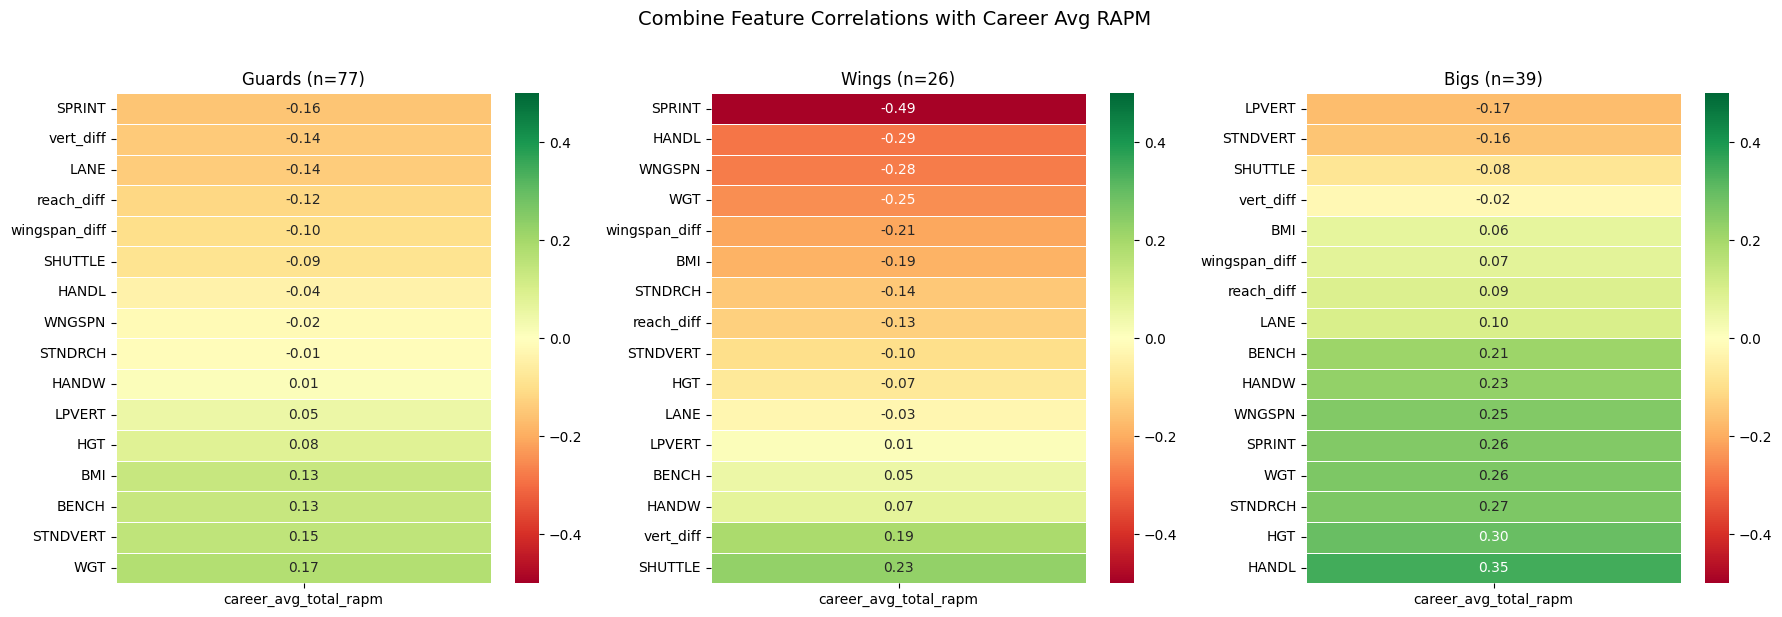

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

COMBINE_FEATURES = [
    "HGT", "WGT", "BMI", "WNGSPN", "STNDRCH",
    "HANDL", "HANDW",
    "STNDVERT", "LPVERT",
    "LANE", "SHUTTLE", "SPRINT",
    "BENCH",
    "wingspan_diff", "reach_diff", "vert_diff",
]

TARGET = "career_avg_total_rapm"

# Correlation heat-map: combine features vs career RAPM, split by position
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, group in zip(axes, ["Guard", "Wing", "Big"]):
    sub = dataset[dataset["pos_group"] == group][COMBINE_FEATURES + [TARGET]].dropna()
    corr = sub.corr()[[TARGET]].drop(TARGET).sort_values(TARGET)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
                vmin=-0.5, vmax=0.5, ax=ax, linewidths=0.5)
    ax.set_title(f"{group}s (n={len(sub)})")
    ax.set_ylabel("")

plt.suptitle("Combine Feature Correlations with Career Avg RAPM", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("combine_corr_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

## ML models by position group
Use 3 regression models:
- **Ridge regression**
- **Random Forest**
- **Gradient Boosting (XGBoost/sklearn)**

In [56]:
from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.linear_model      import RidgeCV
from sklearn.ensemble          import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection   import cross_val_score, KFold
from sklearn.inspection        import permutation_importance
import warnings
warnings.filterwarnings("ignore")

POSITION_GROUPS = ["Guard", "Wing", "Big"]
CV = KFold(n_splits=5, shuffle=True, random_state=42)

# Store results for dashboard export
results       = {}   
importances   = {}   

MODELS = {
    "Ridge":    Pipeline([("imp", SimpleImputer()), ("scl", StandardScaler()), ("mdl", RidgeCV(alphas=[0.1,1,10,100]))]),
    "RF":       Pipeline([("imp", SimpleImputer()), ("mdl", RandomForestRegressor(n_estimators=300, max_features="sqrt", random_state=42))]),
    "GBM":      Pipeline([("imp", SimpleImputer()), ("mdl", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42))]),
}

print("Training models...\n")
for group in POSITION_GROUPS:
    # Rebuild fresh pipelines for each position group
    MODELS = {
        "Ridge": Pipeline([("imp", SimpleImputer()), ("scl", StandardScaler()), ("mdl", RidgeCV(alphas=[0.1,1,10,100]))]),
        "RF":    Pipeline([("imp", SimpleImputer()), ("mdl", RandomForestRegressor(n_estimators=300, max_features="sqrt", random_state=42))]),
        "GBM":  Pipeline([("imp", SimpleImputer()), ("mdl", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42))]),
    }

    sub = dataset[dataset["pos_group"] == group][COMBINE_FEATURES + [TARGET]].dropna(subset=[TARGET])
    X = sub[COMBINE_FEATURES].values
    y = sub[TARGET].values
    print(f"{'='*50}")
    print(f"{group}s — n={len(sub)} players")
    results[group] = {}
    best_model, best_r2 = None, -999

    for name, pipe in MODELS.items():
        scores = cross_val_score(pipe, X, y, cv=CV, scoring="r2")
        results[group][name] = scores
        print(f"  {name:8s}  R² = {scores.mean():.3f}  ±{scores.std():.3f}")
        if scores.mean() > best_r2:
            best_r2, best_model = scores.mean(), (name, pipe)

    # --- Feature importance from RF (fit on full position subset) ---
    rf_pipe = MODELS["RF"]
    rf_pipe.fit(X, y)
    perm = permutation_importance(rf_pipe, X, y, n_repeats=20, random_state=42, scoring="r2")
    imp_df = pd.DataFrame({
        "feature":    COMBINE_FEATURES,
        "importance": perm.importances_mean,
        "std":        perm.importances_std,
    }).sort_values("importance", ascending=False)
    importances[group] = imp_df
    print(f"\n  Top-5 features (permutation importance):")
    print(imp_df.head(5).to_string(index=False))
    print()

Training models...

Guards — n=429 players
  Ridge     R² = -0.062  ±0.052
  RF        R² = -0.014  ±0.051
  GBM       R² = -0.245  ±0.199

  Top-5 features (permutation importance):
      feature  importance      std
         LANE    0.226857 0.014764
   reach_diff    0.148921 0.012147
wingspan_diff    0.145182 0.009166
          BMI    0.108498 0.005574
          WGT    0.103394 0.006217

Wings — n=195 players
  Ridge     R² = -0.067  ±0.092
  RF        R² = 0.100  ±0.295
  GBM       R² = -0.140  ±0.481

  Top-5 features (permutation importance):
feature  importance      std
   LANE    0.171631 0.019253
  BENCH    0.144731 0.013345
    WGT    0.109877 0.007773
    HGT    0.100106 0.009282
    BMI    0.087795 0.004561

Bigs — n=314 players
  Ridge     R² = -0.047  ±0.042
  RF        R² = -0.074  ±0.094
  GBM       R² = -0.451  ±0.422

  Top-5 features (permutation importance):
   feature  importance      std
reach_diff    0.201680 0.048837
       BMI    0.134229 0.009355
     HANDW   

## Create metric importance visuals

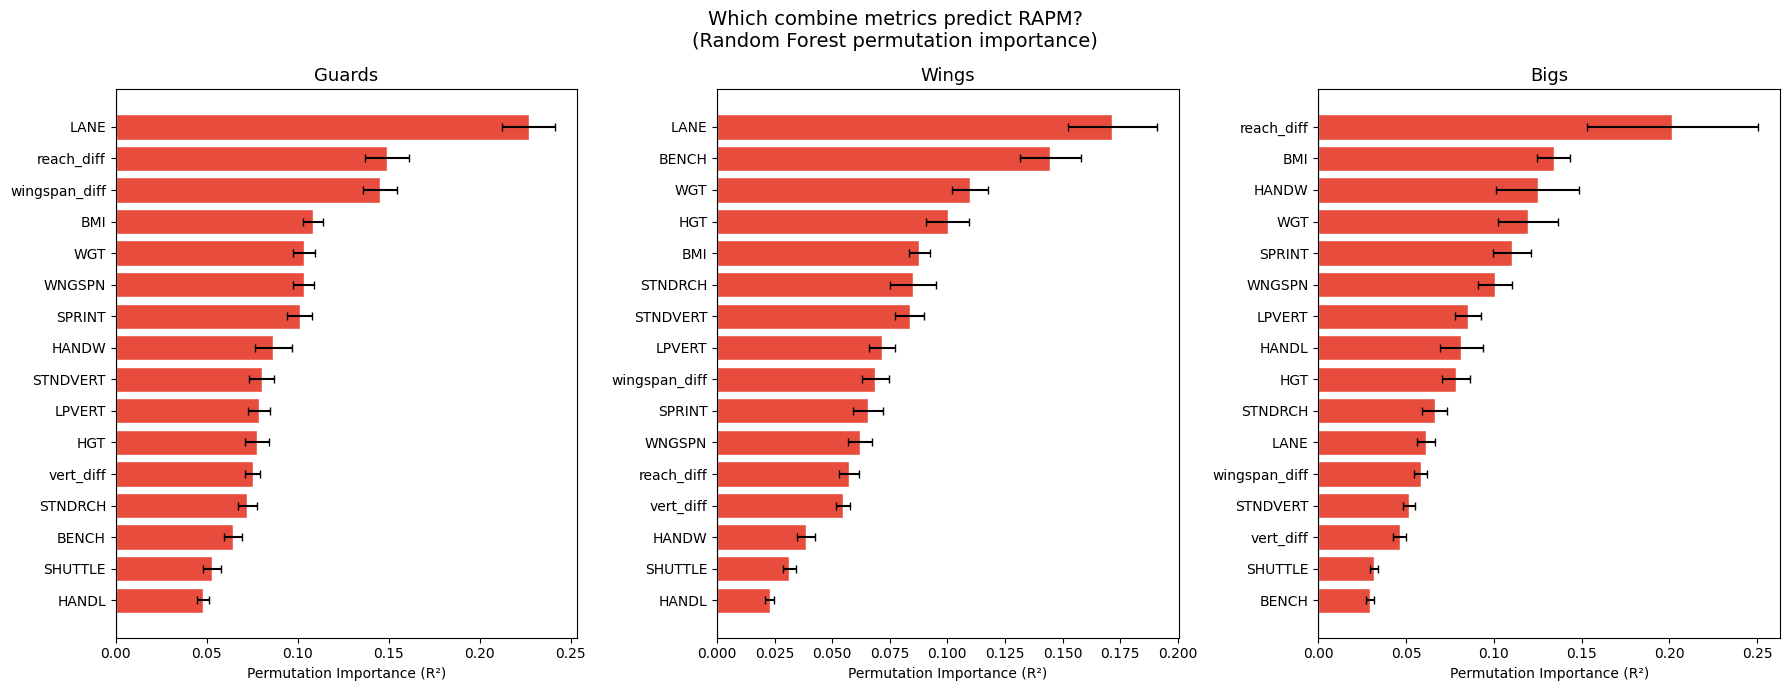

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)

for ax, group in zip(axes, POSITION_GROUPS):
    imp = importances[group].sort_values("importance")
    colors = ["#e74c3c" if v > 0 else "#95a5a6" for v in imp["importance"]]
    ax.barh(imp["feature"], imp["importance"], xerr=imp["std"],
            color=colors, edgecolor="white", capsize=3)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{group}s", fontsize=13)
    ax.set_xlabel("Permutation Importance (R²)")

plt.suptitle("Which combine metrics predict RAPM?\n(Random Forest permutation importance)",
             fontsize=14)
plt.tight_layout()
plt.savefig("combine_importance_by_position.png", bbox_inches="tight", dpi=150)
plt.show()

## Export everything for the Streamlit dashboard

In [59]:
import os, json

os.makedirs("dashboard/data", exist_ok=True)

# 1. Full dataset (for scatter plots, player lookup)
export_cols = ["PLAYER", "YEAR", "POS", "pos_group",
               "draftRound", "draftNumber", "seasons_in_nba"] + COMBINE_FEATURES + [
               TARGET, "career_avg_off_rapm", "peak_total_rapm"]
dataset[export_cols].to_csv("dashboard/data/combine_rapm.csv", index=False)

# 2. Feature importance tables per position
for group, imp_df in importances.items():
    imp_df.to_csv(f"dashboard/data/importance_{group.lower()}.csv", index=False)

# 3. CV R² scores summary
summary = []
for group, model_scores in results.items():
    for model_name, scores in model_scores.items():
        summary.append({"position": group, "model": model_name,
                        "mean_r2": round(scores.mean(), 4),
                        "std_r2":  round(scores.std(), 4)})
pd.DataFrame(summary).to_csv("dashboard/data/model_summary.csv", index=False)

# 4. Feature metadata (human-readable labels for the dashboard)
feature_labels = {
    "HGT":          "Height (in)",
    "WGT":          "Weight (lbs)",
    "BMI":          "BMI",
    "WNGSPN":       "Wingspan (in)",
    "STNDRCH":      "Standing Reach (in)",
    "HANDL":        "Hand Length (in)",
    "HANDW":        "Hand Width (in)",
    "STNDVERT":     "Standing Vertical (in)",
    "LPVERT":       "Max Vertical (in)",
    "LANE":         "Lane Agility (sec)",
    "SHUTTLE":      "Shuttle Run (sec)",
    "SPRINT":       "3/4 Sprint (sec)",
    "BENCH":        "Bench Press (reps)",
    "wingspan_diff": "Wingspan − Height",
    "reach_diff":   "Reach − Height",
    "vert_diff":    "Max − Standing Vertical",
}
with open("dashboard/data/feature_labels.json", "w") as f:
    json.dump(feature_labels, f, indent=2)

print("✅ All dashboard data exported to dashboard/data/")

✅ All dashboard data exported to dashboard/data/


In [61]:
BOX_COLS = [
    "numMinutes", "points", "assists", "reboundsTotal",
    "reboundsDefensive", "reboundsOffensive",
    "steals", "blocks", "turnovers",
    "fieldGoalsMade", "fieldGoalsAttempted", "fieldGoalsPercentage",
    "threePointersMade", "threePointersAttempted", "threePointersPercentage",
    "freeThrowsMade", "freeThrowsAttempted", "freeThrowsPercentage",
]
stats_export = player_stats[player_stats["gameType"] == "Regular Season"].copy()
for c in BOX_COLS:
    stats_export[c] = pd.to_numeric(stats_export[c], errors="coerce")
stats_export = stats_export[stats_export["numMinutes"] > 0]

def p36(col): return stats_export[col] / stats_export["numMinutes"] * 36

stats_export["pts_per36"] = p36("points")
stats_export["ast_per36"] = p36("assists")
stats_export["reb_per36"] = p36("reboundsTotal")
stats_export["reb_def_per36"] = p36("reboundsDefensive")
stats_export["reb_off_per36"] = p36("reboundsOffensive")
stats_export["stl_per36"] = p36("steals")
stats_export["blk_per36"] = p36("blocks")
stats_export["tov_per36"] = p36("turnovers")

# Shooting percentages: use career totals for more stable estimates
career_shooting = (
    stats_export
    .groupby("personId")
    .agg(
        fg_made  = ("fieldGoalsMade",       "sum"),
        fg_att   = ("fieldGoalsAttempted",   "sum"),
        tp_made  = ("threePointersMade",     "sum"),
        tp_att   = ("threePointersAttempted","sum"),
        ft_made  = ("freeThrowsMade",        "sum"),
        ft_att   = ("freeThrowsAttempted",   "sum"),
    )
    .reset_index()
)
career_shooting["fg_pct"]  = career_shooting["fg_made"]  / career_shooting["fg_att"].replace(0, float("nan"))
career_shooting["3p_pct"]  = career_shooting["tp_made"]  / career_shooting["tp_att"].replace(0, float("nan"))
career_shooting["ft_pct"]  = career_shooting["ft_made"]  / career_shooting["ft_att"].replace(0, float("nan"))

# Per-36 averages
boxscore = (
    stats_export
    .groupby("personId")
    .agg(
        pts_per36     = ("pts_per36",     "mean"),
        ast_per36     = ("ast_per36",     "mean"),
        reb_per36     = ("reb_per36",     "mean"),
        stl_per36     = ("stl_per36",     "mean"),
        blk_per36     = ("blk_per36",     "mean"),
        tov_per36     = ("tov_per36",     "mean"),
        total_minutes = ("numMinutes",    "sum"),
    )
    .reset_index()
    .query("total_minutes >= 500")
    .merge(career_shooting[["personId","fg_pct","3p_pct","ft_pct"]], on="personId", how="left")
)

# Bridge to canonical personId (same trick as Step 3)
stats_names_exp = (
    player_stats[["personId","firstName","lastName"]]
    .drop_duplicates("personId")
    .assign(personId=lambda d: d["personId"].astype(str))
)
canonical_exp = (
    players_info[["personId","firstName","lastName"]]
    .rename(columns={"personId":"canonical_id"})
    .assign(canonical_id=lambda d: d["canonical_id"].astype(str))
)
boxscore["personId"] = boxscore["personId"].astype(str)
boxscore = (
    boxscore
    .merge(stats_names_exp, on="personId", how="left")
    .merge(canonical_exp, on=["firstName","lastName"], how="inner")
    .drop(columns=["personId"])
    .rename(columns={"canonical_id":"personId"})
    .drop(columns=["firstName","lastName","total_minutes"])
)

boxscore.to_csv("dashboard/data/boxscore_per36.csv", index=False)
print(f"✅ boxscore_per36.csv exported — {len(boxscore)} players")

✅ boxscore_per36.csv exported — 3284 players
